# [기초-실습] 통계 101×데이터 분석: (4장) 추론통계~신뢰구간

_이 노트북은 LMS에서 내보냈습니다. 영상·퀴즈는 학습 참고용으로 마크다운으로 변환되었습니다._

## ⚙️ 환경 준비 — 한글 폰트 설치 및 라이브러리 불러오기

In [1]:
# 구글 코랩 환경에서 한글 폰트 설치 및 설정하기
# 필요시 아래 코드 실행 후, [런타임] - [세션 다시 시작] 후 셀을 다시 실행하세요.
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Sudo가 이 컴퓨터에서 사용하지 않도록 설정되어 있습니다. 사용하도록 설정하려면 으로 이동하세요. ]8;;ms-settings:developers\Developer Settings page]8;;\ 설정 앱의
Sudo가 이 컴퓨터에서 사용하지 않도록 설정되어 있습니다. 사용하도록 설정하려면 으로 이동하세요. ]8;;ms-settings:developers\Developer Settings page]8;;\ 설정 앱의
'rm'��(��) ���� �Ǵ� �ܺ� ����, ������ �� �ִ� ���α׷�, �Ǵ�
��ġ ������ �ƴմϴ�.


In [2]:
# 파이썬 라이브러리 및 모듈 가져오기
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [5]:
plt.rcParams['font.family'] = 'Malgun Gothic'

# 문제 1. 표본조사 체험하기

**📘 문제**

- 온라인 쇼핑몰은 전체 고객 수가 너무 많아, 모든 고객을 조사하기 어렵습니다.

- 그래서 무작위로 고객 30명을 뽑아 평균 만족도를 계산하고 이를 전체 만족도의 추정값으로 사용하려 합니다.

- 이번 실습에서는 직접 표본을 뽑고, 표본 평균을 구해보며,
  **“표본마다 결과가 달라질 수 있다”**는 추론 통계의 핵심 개념을 체험해봅니다.

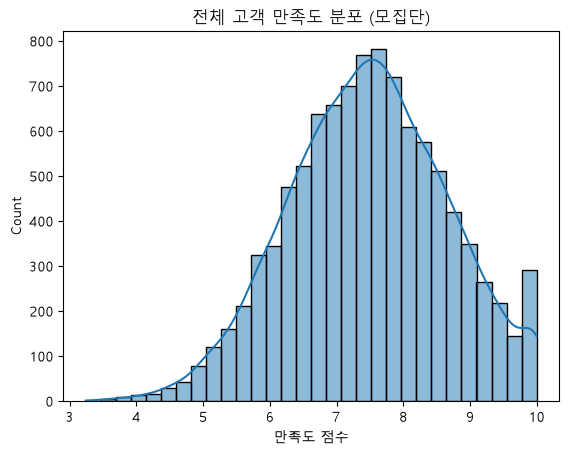

In [6]:
# 모집단 생성 (전체 고객 만족도 10,000명)
np.random.seed(2025)
population = np.random.normal(loc=7.5, scale=1.2, size=10000)
population = np.clip(population, 1, 10)  # 1점 ~ 10점 사이로 제한
df_pop = pd.DataFrame({'score': population})

# 전체 모집단 시각화
sns.histplot(df_pop['score'], bins=30, kde=True)
plt.title("전체 고객 만족도 분포 (모집단)")
plt.xlabel("만족도 점수")
plt.show()

**📌 아래를 수행해 보세요:**

- 표본을 무작위로 여러 번 뽑아 보고, 표본 평균이 어떻게 변하는지 확인해봅시다.

- 히스토그램을 그리고, 표본 평균의 분포 형태를 관찰해봅시다.

표본평균들의 평균: 7.494745643807138
표본평균들의 표준편차: 0.2092509085732419
모집단 평균: 7.480611214490196


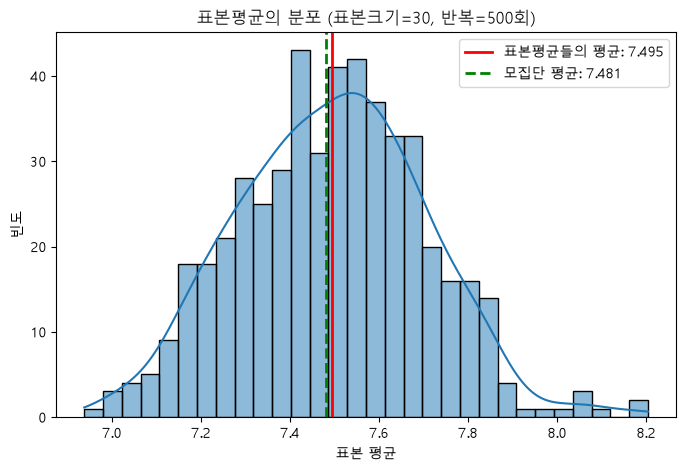

In [9]:
# [문제 1] Q1. 모집단에서 무작위로 30명을 뽑아 표본 평균을 구해봅시다.
# 여기에 코드를 작성해주세요.
# 표본을 여러 번 뽑아서 표본 평균 구하기
np.random.seed(2025)

n_samples = 500      # 표본을 뽑는 횟수
sample_size = 30       # 한 번 뽑을 때 표본 크기

# [문제 1] Q2. 이 과정을 500번 반복하고, 표본 평균을 리스트에 저장합니다.
sample_means = []

for i in range(n_samples):
    sample = np.random.choice(df_pop['score'], size=sample_size, replace=False)
    sample_means.append(sample.mean())

sample_means = np.array(sample_means)

print("표본평균들의 평균:", sample_means.mean())
print("표본평균들의 표준편차:", sample_means.std())
print("모집단 평균:", df_pop['score'].mean())

# [문제 1] Q3. 표본 평균들의 분포를 히스토그램으로 그려봅시다. 평균선도 함께 표시해 봅시다.
plt.figure(figsize=(8, 5))
sns.histplot(sample_means, bins=30, kde=True)

# 표본평균들의 평균선 (빨간 실선)
plt.axvline(sample_means.mean(), color='red', linestyle='-', linewidth=2, 
            label=f'표본평균들의 평균: {sample_means.mean():.3f}')

# 모집단 평균선 (초록 점선)
plt.axvline(df_pop['score'].mean(), color='green', linestyle='--', linewidth=2, 
            label=f'모집단 평균: {df_pop["score"].mean():.3f}')

plt.title(f"표본평균의 분포 (표본크기={sample_size}, 반복={n_samples}회)")
plt.xlabel("표본 평균")
plt.ylabel("빈도")
plt.legend()
plt.show()

**🧠 데이터를 어떻게 읽을까요?**

- 표본 평균들은 어떤 값 주변에 많이 분포해 있나요? 이 값은 전체 모집단 평균과 얼마나 비슷한가요?

- 표본을 1번 뽑았을 때와 500번을 반복해서 뽑았을 때, 표본 평균의 분포나 신뢰성에는 어떤 차이가 있나요

- 친구가 다른 표본을 뽑았다면 같은 평균이 나왔을까요? 비슷한 결과가 나왔더라도 완전히 같지 않았다면, 그 이유는 무엇일까요?

- 표본 평균들의 분포는 어떤 모양인가요? 종 모양의 정규분포처럼 보이나요? 그렇다면 왜 그렇게 되는 걸까요?

In [11]:
# [문제 1] 데이터를 어떻게 읽을까요?
print("[1번 질문]")
print(f"표본 평균들은 {sample_means.mean():.3f}점 주변에 많이 몰려 있습니다.")
print(f"이 값은 모집단 평균인 {df_pop['score'].mean():.3f}점과 거의 차이가 없습니다.")
print("이는 표본 평균이 모집단 평균의 매우 좋은 추정치가 될 수 있음을 보여줍니다.")
print()

print("[2번 질문]")
print("표본을 1번만 뽑았을 때는 그 표본 평균이 우연히 모집단 평균보다 크거나 작을 수 있고,")
print("이 값 하나만으로는 그것이 모집단을 잘 대표하는지 판단하기 어렵습니다.")
print("반면 500번 반복해서 뽑으면, 표본 평균들이 어떤 값 주변에 모이는 '분포'가 보이기 때문에")
print("모집단 평균이 대략 어디쯤인지, 그리고 표본 평균이 얼마나 들쭉날쭉할 수 있는지(변동성)까지 함께 파악할 수 있어")
print("훨씬 더 신뢰할 수 있는 정보를 얻게 됩니다.")
print()

print("[3번 질문]")
print("친구가 뽑은 표본은 무작위로 선택된 다른 데이터이므로, 완전히 같은 평균이 나오기는 어렵습니다.")
print("비슷한 값이 나왔더라도 완전히 같지 않은 이유는, 표본이 모집단에서 '무작위로' 추출되기 때문에")
print("매번 어떤 사람이 뽑히는지가 달라지고, 그에 따라 표본에 포함된 값들의 조합도 달라지기 때문입니다.")
print("하지만 표본의 개수가(n) 커진다면 친구의 표본 평균과 제 표본 평균 값이 비슷해질 것입니다.")
print()

print("[4번 질문]")
print("표본 평균들의 분포는 종 모양의 정규분포에 가까운 형태를 보입니다.")
print("이는 모집단 자체가 정규분포를 따르기 때문이기도 하지만,")
print("표본의 크기가 30으로 적당하게 크기 때문입니다.")
print("그리고 추가로, 모집단이 정규분포가 아니더라도 이번 예시처럼 표본 크기가 충분히 크다면")
print("표본 평균의 분포는 정규분포에 가까워질 수 있는데, 이를 '중심극한정리(Central Limit Theorem)'라고 합니다.")
print("즉 개별 데이터 하나하나는 들쭉날쭉해도, 여러 개를 평균 낸 값들끼리 모아보면")
print("평균 주변에 몰리고 양쪽으로 갈수록 줄어드는 안정적인 종 모양이 나타나게 됩니다.")

[1번 질문]
표본 평균들은 7.495점 주변에 많이 몰려 있습니다.
이 값은 모집단 평균인 7.481점과 거의 차이가 없습니다.
이는 표본 평균이 모집단 평균의 매우 좋은 추정치가 될 수 있음을 보여줍니다.

[2번 질문]
표본을 1번만 뽑았을 때는 그 표본 평균이 우연히 모집단 평균보다 크거나 작을 수 있고,
이 값 하나만으로는 그것이 모집단을 잘 대표하는지 판단하기 어렵습니다.
반면 500번 반복해서 뽑으면, 표본 평균들이 어떤 값 주변에 모이는 '분포'가 보이기 때문에
모집단 평균이 대략 어디쯤인지, 그리고 표본 평균이 얼마나 들쭉날쭉할 수 있는지(변동성)까지 함께 파악할 수 있어
훨씬 더 신뢰할 수 있는 정보를 얻게 됩니다.

[3번 질문]
친구가 뽑은 표본은 무작위로 선택된 다른 데이터이므로, 완전히 같은 평균이 나오기는 어렵습니다.
비슷한 값이 나왔더라도 완전히 같지 않은 이유는, 표본이 모집단에서 '무작위로' 추출되기 때문에
매번 어떤 사람이 뽑히는지가 달라지고, 그에 따라 표본에 포함된 값들의 조합도 달라지기 때문입니다.
하지만 표본의 개수가(n) 커진다면 친구의 표본 평균과 제 표본 평균 값이 비슷해질 것입니다.

[4번 질문]
표본 평균들의 분포는 종 모양의 정규분포에 가까운 형태를 보입니다.
이는 모집단 자체가 정규분포를 따르기 때문이기도 하지만,
표본의 크기가 30으로 적당하게 크기 때문입니다.
그리고 추가로, 모집단이 정규분포가 아니더라도 이번 예시처럼 표본 크기가 충분히 크다면
표본 평균의 분포는 정규분포에 가까워질 수 있는데, 이를 '중심극한정리(Central Limit Theorem)'라고 합니다.
즉 개별 데이터 하나하나는 들쭉날쭉해도, 여러 개를 평균 낸 값들끼리 모아보면
평균 주변에 몰리고 양쪽으로 갈수록 줄어드는 안정적인 종 모양이 나타나게 됩니다.


# 문제 2. 중심극한정리

**📘 문제**

- 현실에서는 모집단의 분포가 정규분포가 아닐 수도 있습니다.

- 예를 들어, 일부 고객은 매우 높은 점수를 주고, 대부분은 낮은 점수를 주는 만족도 분포가 있을 수 있죠. (예: 지수분포)

- 이처럼 원래 분포가 비정규분포여도,
  표본을 여러 번 뽑아 평균을 계산하면, 그 평균들의 분포는 정규분포에 가까워진다는 것을
  **중심극한정리(Central Limit Theorem)**라고 합니다.

- 이번 실습에서는 다양한 크기의 표본을 뽑아 평균을 계산하고,
  그 평균들의 분포가 어떻게 변하는지를 직접 실험해 봅니다.

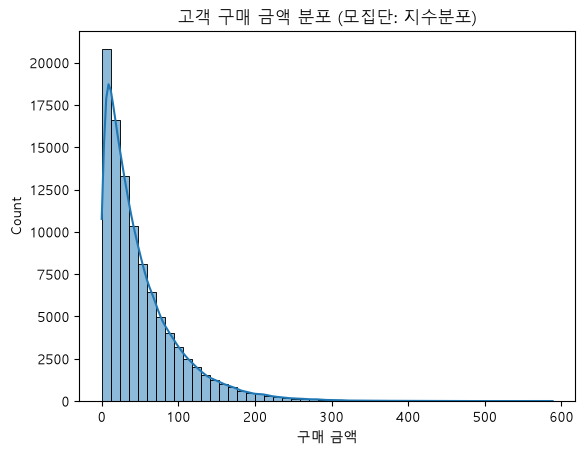

In [12]:
# 지수분포를 따르는 모집단 생성
np.random.seed(2025)
population = np.random.exponential(scale=50, size=100000)  # 평균 50, 비대칭 분포

# 모집단 시각화
sns.histplot(population, bins=50, kde=True)
plt.title("고객 구매 금액 분포 (모집단: 지수분포)")
plt.xlabel("구매 금액")
plt.show()

**📌 아래를 수행해 보세요:**

- 비대칭적인 모집단(지수분포)에서 무작위로 표본을 추출해 평균을 구해봅시다.

- 표본 크기를 바꿔가며, 표본 평균들의 분포가 어떻게 변화하는지 확인해봅시다.

- 히스토그램을 그리고, 분포의 모양을 관찰해봅시다.

- 표본 크기가 커질수록 표본 평균 분포의 모양과 **퍼진 정도(분산)**가 어떻게 변하는지 관찰해봅시다.

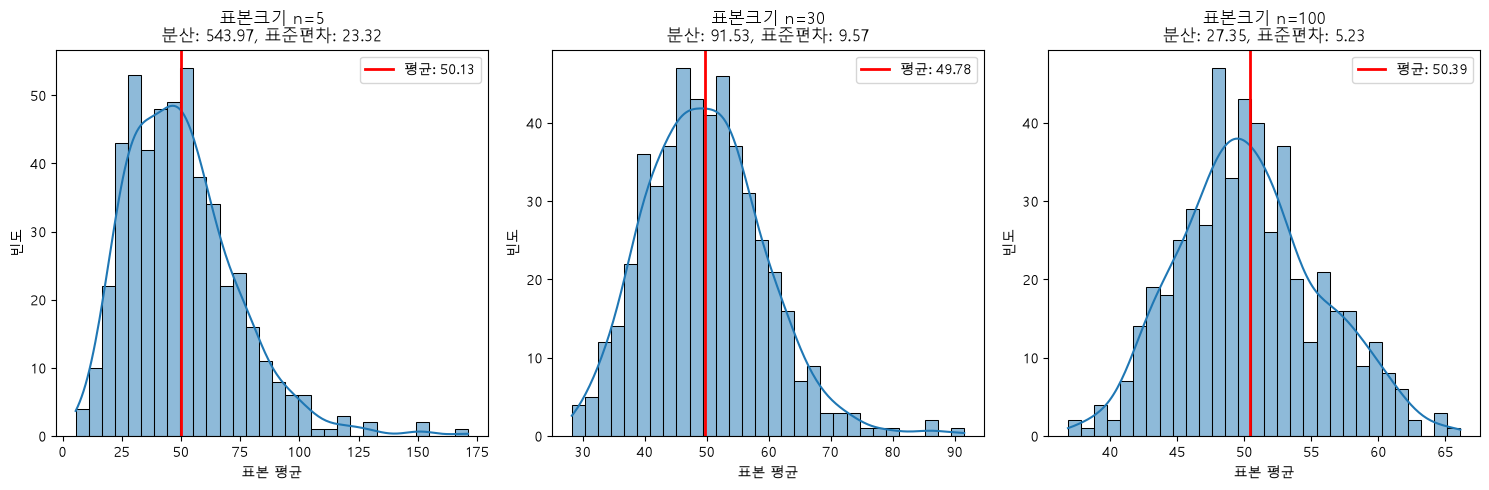

In [13]:
# [문제 2] Q1. 모집단에서 표본을 1000번 뽑고, 각 표본의 평균을 구해봅시다.
# 표본 크기 = 5, 30, 100일 때
np.random.seed(2025)

n_samples = 500
sample_sizes = [5, 30, 100]

results = {}  # 표본크기별 표본평균 배열 저장

for size in sample_sizes:
    sample_means = []
    for _ in range(n_samples):
        sample = np.random.choice(population, size=size, replace=False)
        sample_means.append(sample.mean())
    results[size] = np.array(sample_means)


# 각 표본 크기별로 표본 평균들의 분포를 히스토그램으로 그려봅시다. 평균선도 함께 표시해 봅시다.
# 나란히 히스토그램 그리기
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, size in zip(axes, sample_sizes):
    means = results[size]
    
    sns.histplot(means, bins=30, kde=True, ax=ax)
    
    # 평균선
    ax.axvline(means.mean(), color='red', linestyle='-', linewidth=2,
               label=f'평균: {means.mean():.2f}')
    
    ax.set_title(f"표본크기 n={size}\n분산: {means.var():.2f}, 표준편차: {means.std():.2f}")
    ax.set_xlabel("표본 평균")
    ax.set_ylabel("빈도")
    ax.legend()

plt.tight_layout()
plt.show()

**🧠 데이터를 어떻게 읽을까요?**

- 표본 크기가 작을 때 (예: 5), 평균들의 분포는 어떤 모양인가요? -> 치우쳐진 종 모양

- 표본 크기가 커질수록 평균 분포의 모양은 어떤 변화를 보이나요? -> 정규분포와 비슷한 형태가 됨

- 원래 모집단은 비대칭이었는데, 왜 평균들의 분포는 정규분포처럼 바뀌었을까요? -> 표본의 크기가 충분히 커졌기 때문

- 이 실험을 통해 중심극한정리를 어떻게 이해하게 되었나요? -> 모분포가 정규분포가 아니어도, 표본의 크기가 충분히 크다면, 표본평균의 분포는 정규분포를 따를 수 있다

- 표본 크기에 따라 **분포의 넓이(흩어짐)**는 어떻게 달라지나요? -> 표본의 크기가 커질수록 분산도는 점점 작아진다 

In [14]:
# [문제 2]데이터를 어떻게 읽을까요?
print("[1번 질문]")
print("표본 크기가 n=5로 작을 때, 표본 평균들의 분포는 오른쪽으로 꼬리가 긴 비대칭 형태를 보입니다.")
print("원래 모집단인 지수분포의 비대칭성이 표본 크기가 작을 때는 표본평균에도 그대로 남아있기 때문입니다.")
print()

print("[2번 질문]")
print("표본 크기가 n=5 → 30 → 100으로 커질수록, 표본 평균들의 분포는 점점 좌우 대칭에 가까운")
print("종 모양(정규분포 형태)으로 바뀝니다. n=30만 되어도 이미 꽤 정규분포에 가까운 모양이 나타나고,")
print("n=100에서는 훨씬 더 매끄럽고 대칭적인 종 모양을 보입니다.")
print()

print("[3번 질문]")
print("원래 모집단(지수분포)은 비대칭이지만, 표본평균은 여러 개의 값을 더해서 나눈 것이기 때문에")
print("극단적으로 크거나 작은 값 하나가 전체 평균에 미치는 영향이 표본 크기가 커질수록 줄어듭니다.")
print("이렇게 여러 관측치가 서로 상쇄되면서 평균값들이 특정 지점 주변으로 모이게 되고,")
print("표본 크기가 충분히 크면 그 분포가 정규분포에 가까워지는데, 이것이 바로 중심극한정리입니다.")
print()

print("[4번 질문]")
print("이 실험을 통해 모집단의 분포 모양과 상관없이, 표본 크기만 충분히 크다면")
print("표본평균의 분포는 정규분포로 근사할 수 있다는 것을 직접 눈으로 확인할 수 있었습니다.")
print("이는 실제로 모집단 분포를 몰라도 표본평균을 이용한 통계적 추론(신뢰구간, 가설검정 등)이")
print("가능한 이론적 근거가 됩니다.")
print()

print("[5번 질문]")
print("표본 크기가 커질수록 표본평균 분포의 흩어진 정도(분산, 표준편차)는 뚜렷하게 줄어듭니다.")
print("실제로 n=5일 때 분산 543.97(표준편차 23.32)이었던 것이, n=30에서는 분산 91.53(표준편차 9.57),")
print("n=100에서는 분산 27.35(표준편차 5.23)로 표본 크기가 커질수록 크게 감소했습니다.")
print("이는 표본 크기가 커질수록 표본평균이 모평균 근처로 더 좁게 모이며 추정의 신뢰도가 높아짐을 보여줍니다.")

[1번 질문]
표본 크기가 n=5로 작을 때, 표본 평균들의 분포는 오른쪽으로 꼬리가 긴 비대칭 형태를 보입니다.
원래 모집단인 지수분포의 비대칭성이 표본 크기가 작을 때는 표본평균에도 그대로 남아있기 때문입니다.

[2번 질문]
표본 크기가 n=5 → 30 → 100으로 커질수록, 표본 평균들의 분포는 점점 좌우 대칭에 가까운
종 모양(정규분포 형태)으로 바뀝니다. n=30만 되어도 이미 꽤 정규분포에 가까운 모양이 나타나고,
n=100에서는 훨씬 더 매끄럽고 대칭적인 종 모양을 보입니다.

[3번 질문]
원래 모집단(지수분포)은 비대칭이지만, 표본평균은 여러 개의 값을 더해서 나눈 것이기 때문에
극단적으로 크거나 작은 값 하나가 전체 평균에 미치는 영향이 표본 크기가 커질수록 줄어듭니다.
이렇게 여러 관측치가 서로 상쇄되면서 평균값들이 특정 지점 주변으로 모이게 되고,
표본 크기가 충분히 크면 그 분포가 정규분포에 가까워지는데, 이것이 바로 중심극한정리입니다.

[4번 질문]
이 실험을 통해 모집단의 분포 모양과 상관없이, 표본 크기만 충분히 크다면
표본평균의 분포는 정규분포로 근사할 수 있다는 것을 직접 눈으로 확인할 수 있었습니다.
이는 실제로 모집단 분포를 몰라도 표본평균을 이용한 통계적 추론(신뢰구간, 가설검정 등)이
가능한 이론적 근거가 됩니다.

[5번 질문]
표본 크기가 커질수록 표본평균 분포의 흩어진 정도(분산, 표준편차)는 뚜렷하게 줄어듭니다.
실제로 n=5일 때 분산 543.97(표준편차 23.32)이었던 것이, n=30에서는 분산 91.53(표준편차 9.57),
n=100에서는 분산 27.35(표준편차 5.23)로 표본 크기가 커질수록 크게 감소했습니다.
이는 표본 크기가 커질수록 표본평균이 모평균 근처로 더 좁게 모이며 추정의 신뢰도가 높아짐을 보여줍니다.


# 문제 3. 표준오차

**📘 문제**

- 앞선 실습에서 우리는 **표본 크기(n)가 커질수록 표본 평균들의 분포가 더 좁아진다**는 것을 확인했습니다.
- 이처럼 표본 평균들이 얼마나 흩어져 있는지(분포의 퍼진 정도)를 나타내는 값을 **표준오차(Standard Error, SE)**라고 부릅니다.
- 표준오차는 **표본 평균들의 표준편차**와 같은 의미이며, 이는 우리가 뽑은 표본 평균이 실제 모평균과 평균적으로 얼마나 떨어져 있을지를 나타내는 **'예상 오차의 크기'**입니다.

- 통계학적으로 이 표준오차는 **`SE = σ / √n`** (모집단 표준편차 / 표본 크기의 제곱근) 이라는 공식으로 계산할 수 있습니다.
- 이 공식은 **표본 크기(n)가 커질수록 표준오차(SE)가 작아진다**는 것을 명확히 보여줍니다.

- 이번 실습에서는 여러 크기의 표본을 뽑아, 시뮬레이션을 통해 얻은 **표본 평균들의 표준편차(실험값)**가 공식으로 계산한 **표준오차(이론값)**와 얼마나 일치하는지 직접 확인해봅니다.

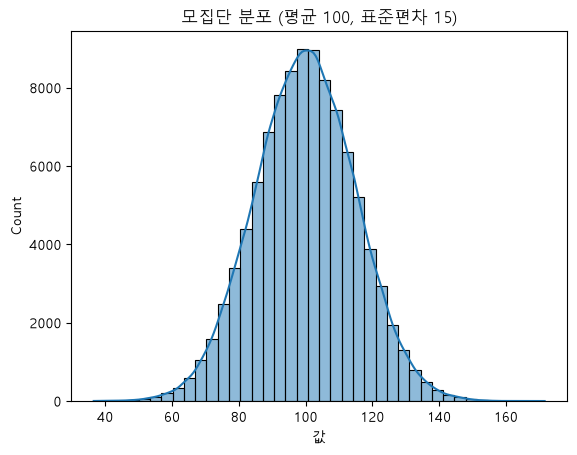

In [30]:
# 모집단 생성 (평균 100, 표준편차 15)
np.random.seed(2025)
population = np.random.normal(loc=100, scale=15, size=100000)

# 모집단 시각화
sns.histplot(population, bins=40, kde=True)
plt.title("모집단 분포 (평균 100, 표준편차 15)")
plt.xlabel("값")
plt.show()

**📌 아래를 수행해 보세요:**

- 모집단에서 여러 크기의 표본(10, 30, 100, 500)을 각각 1000번 뽑고, 그 평균들을 구한 뒤, **표본 평균들의 표준편차(=실험적 표준오차)**를 계산해봅시다.

- 이 결과를 이론적인 표준오차 공식과 비교하는 표를 만들고, 시각화해봅시다.

표본크기별 실험적 표준오차:
n=10: SE(실험값) = 4.5587
n=30: SE(실험값) = 2.7465
n=100: SE(실험값) = 1.4923
n=500: SE(실험값) = 0.6532
   표본크기(n)   실험값(SE)   이론값(SE)        차이
0       10  4.558660  4.753921  0.195261
1       30  2.746502  2.744677  0.001825
2      100  1.492328  1.503322  0.010994
3      500  0.653220  0.672306  0.019086


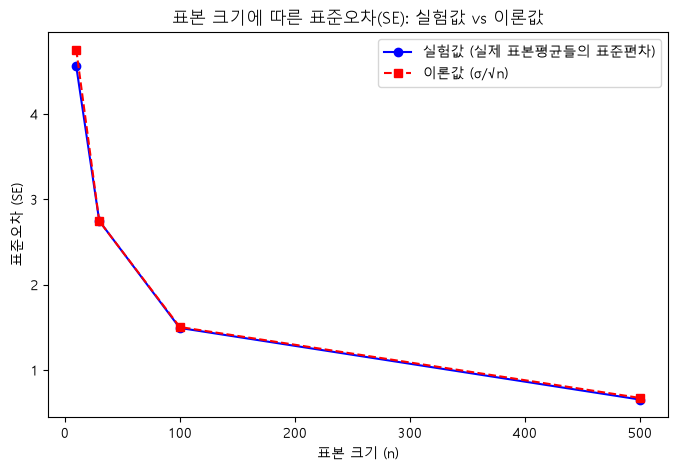

In [31]:
# [문제 3] Q1. 표본 크기 10, 30, 100, 500에 대해 각각 1000번 표본을 뽑고, 평균을 구해봅시다.
# 각 표본 평균 분포의 표준편차를 계산해봅시다.
# 결과를 리스트에 저장하고, 표로 정리해봅시다.

np.random.seed(2025)

n_samples = 1000
sample_sizes = [10, 30, 100, 500]

results = {}          # 표본크기별 표본평균 배열 저장
se_experimental_list = []   # 실험적 표준오차 저장

for size in sample_sizes:
    sample_means = []
    for _ in range(n_samples):
        sample = np.random.choice(population, size=size, replace=False)
        sample_means.append(sample.mean())
    sample_means = np.array(sample_means)
    
    results[size] = sample_means
    se_experimental_list.append(sample_means.std())

print("표본크기별 실험적 표준오차:")
for size, se in zip(sample_sizes, se_experimental_list):
    print(f"n={size}: SE(실험값) = {se:.4f}")

# 이론적인 표준오차와 비교해봅시다. [공식] 표준오차(SE) = 모집단 표준편차 / √표본크기
sigma = population.std()  # 모집단 표준편차

se_theoretical_list = [sigma / np.sqrt(size) for size in sample_sizes]

df_se = pd.DataFrame({
    '표본크기(n)': sample_sizes,
    '실험값(SE)': se_experimental_list,
    '이론값(SE)': se_theoretical_list,
    '차이': [abs(exp - theo) for exp, theo in zip(se_experimental_list, se_theoretical_list)]
})

print(df_se)

# 실험값과 이론값을 시각화해봅시다. 표본 크기를 x축, 표준오차를 y축으로 한 꺾은선 그래프를 그려봅시다.
plt.figure(figsize=(8, 5))

plt.plot(sample_sizes, se_experimental_list, marker='o', linestyle='-', 
         color='blue', label='실험값 (실제 표본평균들의 표준편차)')
plt.plot(sample_sizes, se_theoretical_list, marker='s', linestyle='--', 
         color='red', label='이론값 (σ/√n)')

plt.title("표본 크기에 따른 표준오차(SE): 실험값 vs 이론값")
plt.xlabel("표본 크기 (n)")
plt.ylabel("표준오차 (SE)")
plt.legend()
plt.show()

**🧠 데이터를 어떻게 읽을까요?**

- 표본 크기가 작을수록, 표본 평균의 분포는 어떤 모양인가요? 넓게 퍼져 있나요? -> 작을수록 퍼져있음

- 표본 크기가 커질수록, 평균 분포는 어떻게 변하나요? -> 더 평균으로 몰려있음(분산이 작음)

- 실험값과 이론값(공식 계산값)은 얼마나 비슷한가요? -> 차이가 거의 나지 않는다. 

- 왜 표본 크기가 커질수록 표준오차는 작아질까요? -> 이론 공식에의하면, n이 커질수록 값이 작아지는 구조이기 때문이다. 그리고 좀 더 자세히 설명하자면, 표본의 크기가 커질수록 극단값의 영향이 줄어들기 때문에 모분포의 영향을 덜 받기 때문이라고도 할 수 있다. 

In [32]:
# [문제 3] 데이터를 어떻게 읽을까요?
print("[1번 질문]")
print("표본 크기가 작을 때(n=10), 표준오차는 약 4.6~4.7 정도로 상대적으로 크게 나타납니다.")
print("작을수록 표본 평균들이 넓게 퍼져 있다는 뜻이며, 표본 하나하나의 평균값이 서로")
print("크게 차이날 수 있고 모집단 평균(100)에서 꽤 벗어난 값이 나올 가능성도 높습니다.")
print()

print("[2번 질문]")
print("표본 크기가 n=10 → 30 → 100 → 500으로 커질수록, 표준오차는 약 4.7 → 2.7 → 1.5 → 0.7로")
print("점점 작아집니다. 즉 표본 평균들이 더 평균으로 몰리게 되고(분산이 작아짐),")
print("표본 평균 하나하나가 모집단 평균(100)에 더 가까워지며 예측의 신뢰도가 높아집니다.")
print()

print("[3번 질문]")
print("실험값(파란 실선)과 이론값(빨간 점선)은 표본 크기 전 구간에서 거의 일치하며,")
print("그래프상에서 두 선이 거의 겹쳐 보일 정도로 차이가 거의 나지 않습니다.")
print("이는 SE = σ/√n 이라는 이론적 공식이 실제 시뮬레이션 결과와 잘 맞아떨어짐을 보여줍니다.")
print()

print("[4번 질문]")
print("이론 공식(SE = σ/√n)에 의하면, 분모에 n의 제곱근이 있는 구조이기 때문에")
print("n이 커질수록 값이 작아질 수밖에 없습니다. 좀 더 자세히 설명하자면, 표본의 크기가")
print("커질수록 극단값의 영향이 줄어들기 때문에 모분포의 영향을 덜 받게 되기 때문이라고도 할 수 있습니다.")
print("다만 n이 커질수록 SE가 줄어드는 속도는 점점 완만해지는데(√n에 반비례하므로),")
print("이는 그래프에서 n=10→30 구간의 감소폭에 비해 n=100→500 구간의")
print("감소폭이 상대적으로 작아지는 모습으로도 확인할 수 있습니다.")

[1번 질문]
표본 크기가 작을 때(n=10), 표준오차는 약 4.6~4.7 정도로 상대적으로 크게 나타납니다.
작을수록 표본 평균들이 넓게 퍼져 있다는 뜻이며, 표본 하나하나의 평균값이 서로
크게 차이날 수 있고 모집단 평균(100)에서 꽤 벗어난 값이 나올 가능성도 높습니다.

[2번 질문]
표본 크기가 n=10 → 30 → 100 → 500으로 커질수록, 표준오차는 약 4.7 → 2.7 → 1.5 → 0.7로
점점 작아집니다. 즉 표본 평균들이 더 평균으로 몰리게 되고(분산이 작아짐),
표본 평균 하나하나가 모집단 평균(100)에 더 가까워지며 예측의 신뢰도가 높아집니다.

[3번 질문]
실험값(파란 실선)과 이론값(빨간 점선)은 표본 크기 전 구간에서 거의 일치하며,
그래프상에서 두 선이 거의 겹쳐 보일 정도로 차이가 거의 나지 않습니다.
이는 SE = σ/√n 이라는 이론적 공식이 실제 시뮬레이션 결과와 잘 맞아떨어짐을 보여줍니다.

[4번 질문]
이론 공식(SE = σ/√n)에 의하면, 분모에 n의 제곱근이 있는 구조이기 때문에
n이 커질수록 값이 작아질 수밖에 없습니다. 좀 더 자세히 설명하자면, 표본의 크기가
커질수록 극단값의 영향이 줄어들기 때문에 모분포의 영향을 덜 받게 되기 때문이라고도 할 수 있습니다.
다만 n이 커질수록 SE가 줄어드는 속도는 점점 완만해지는데(√n에 반비례하므로),
이는 그래프에서 n=10→30 구간의 감소폭에 비해 n=100→500 구간의
감소폭이 상대적으로 작아지는 모습으로도 확인할 수 있습니다.


# 문제 4. 신뢰구간 계산과 해석

**📘 문제**

- 표본 평균은 모집단 평균을 추정하는 좋은 점 추정(Point Estimation) 값이지만, 표본오차 때문에 정확히 일치하지는 않습니다.

- 그래서 우리는 "모집단 평균이 아마 이 범위 안에 있을 것이다"라고 **구간으로 추정(Interval Estimation)**하는 것이 더 합리적입니다. 이때 사용하는 개념이 바로 **신뢰구간(Confidence Interval)**입니다.

- 신뢰구간은 표본평균 ± 오차범위 형태로 계산되며, 이 오차범위는 신뢰수준(예: 95%, 99%)과 표본오차에 의해 결정됩니다.

- 이번 실습에서는 **모집단 표준편차(σ)를 알 때(z-분포)**와 **모를 때(t-분포)**의 신뢰구간을 각각 계산해보고, 신뢰수준에 따라 구간의 폭이 어떻게 변하는지 확인해봅니다.

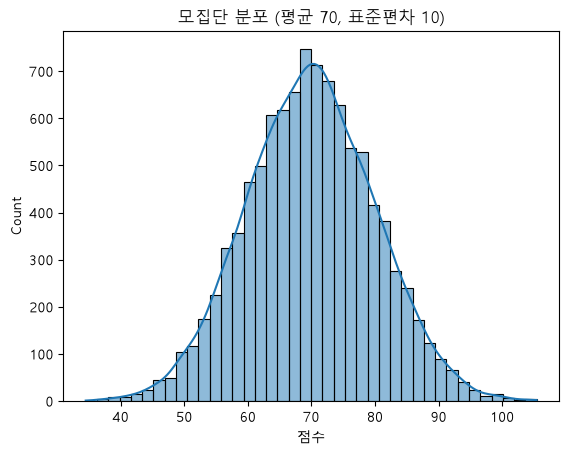

In [23]:
# 모집단 생성
np.random.seed(2025)
population = np.random.normal(loc=70, scale=10, size=10000)

# 모집단 시각화
sns.histplot(population, bins=40, kde=True)
plt.title("모집단 분포 (평균 70, 표준편차 10)")
plt.xlabel("점수")
plt.show()

**📌 아래를 수행해 보세요:**

- 모집단에서 30명을 무작위로 뽑아 평균, 표준편차, 표준오차를 계산해보세요.

- 95% 신뢰구간을 z-분포와 t-분포를 각각 사용해서 계산해보세요.

- 신뢰수준을 바꿨을 때(90%, 99%) 신뢰구간이 어떻게 변하는지 확인해보세요.

In [24]:
# [문제 4] Q1. 모집단에서 표본 30명을 무작위로 추출하고, 표본 평균과 표준편차를 구해봅시다. 표준오차도 함께 계산해보세요.
np.random.seed(2025)

n = 30
sample = np.random.choice(population, size=n, replace=False)

sample_mean = sample.mean()
sample_std = sample.std(ddof=1)   # 표본표준편차는 ddof=1 (n-1로 나눔)
sample_se = sample_std / np.sqrt(n)

print(f"표본 평균: {sample_mean:.4f}")
print(f"표본 표준편차: {sample_std:.4f}")
print(f"표준오차(SE): {sample_se:.4f}")

표본 평균: 69.2062
표본 표준편차: 7.8755
표준오차(SE): 1.4379


In [25]:
# [문제 4] Q2. 모집단의 표준편차를 알고 있다고 가정하고, z-분포를 사용하여 95% 신뢰구간을 계산해봅시다.
from scipy import stats

sigma = population.std()   # 모집단 표준편차 (알고 있다고 가정)

confidence = 0.95
z_critical = stats.norm.ppf(1 - (1 - confidence) / 2)   # 95%일 때 약 1.96

se_z = sigma / np.sqrt(n)   # 모표준편차 기반 표준오차
margin_of_error_z = z_critical * se_z

ci_z_lower = sample_mean - margin_of_error_z
ci_z_upper = sample_mean + margin_of_error_z

print(f"z-critical 값: {z_critical:.4f}")
print(f"오차범위(margin of error): {margin_of_error_z:.4f}")
print(f"95% 신뢰구간 (z-분포): ({ci_z_lower:.4f}, {ci_z_upper:.4f})")

z-critical 값: 1.9600
오차범위(margin of error): 3.5802
95% 신뢰구간 (z-분포): (65.6260, 72.7864)


In [26]:
# [문제 4] Q3. 모집단의 표준편차를 모른다고 가정하고, 표본 표준편차와 t-분포를 사용하여 95% 신뢰구간을 계산해봅시다.
confidence = 0.95
df = n - 1   # 자유도 (degree of freedom) = n-1

t_critical = stats.t.ppf(1 - (1 - confidence) / 2, df=df)

se_t = sample_std / np.sqrt(n)   # 표본표준편차 기반 표준오차 (Q1에서 구한 sample_se와 동일)
margin_of_error_t = t_critical * se_t

ci_t_lower = sample_mean - margin_of_error_t
ci_t_upper = sample_mean + margin_of_error_t

print(f"t-critical 값 (df={df}): {t_critical:.4f}")
print(f"오차범위(margin of error): {margin_of_error_t:.4f}")
print(f"95% 신뢰구간 (t-분포): ({ci_t_lower:.4f}, {ci_t_upper:.4f})")

t-critical 값 (df=29): 2.0452
오차범위(margin of error): 2.9408
95% 신뢰구간 (t-분포): (66.2654, 72.1469)


In [27]:
# [문제 4] Q4. 신뢰수준을 90%, 99%로 바꿔가며 신뢰구간을 계산해보고, 그 폭을 비교해봅시다.
confidence_levels = [0.90, 0.95, 0.99]

print("=== t-분포 기준 신뢰구간 비교 ===")
for confidence in confidence_levels:
    t_critical = stats.t.ppf(1 - (1 - confidence) / 2, df=n-1)
    margin_of_error = t_critical * se_t
    
    ci_lower = sample_mean - margin_of_error
    ci_upper = sample_mean + margin_of_error
    width = ci_upper - ci_lower
    
    print(f"신뢰수준 {int(confidence*100)}%: ({ci_lower:.4f}, {ci_upper:.4f})  →  폭: {width:.4f}")

=== t-분포 기준 신뢰구간 비교 ===
신뢰수준 90%: (66.7631, 71.6493)  →  폭: 4.8862
신뢰수준 95%: (66.2654, 72.1469)  →  폭: 5.8815
신뢰수준 99%: (65.2429, 73.1695)  →  폭: 7.9266


**🧠 데이터를 어떻게 읽을까요?**

- z-분포와 t-분포를 사용한 신뢰구간은 얼마나 차이가 있나요?

- 신뢰수준이 높아질수록 신뢰구간의 폭은 어떻게 변하나요? 왜 그럴까요? -> 모수를 포함할 확률이 더 커져야하니까 넓어지게 됨

- 신뢰구간이 넓다는 건 좋은 걸까요? 나쁜 걸까요? -> 너무 넓다는 건 추정하는 의미가 없어질 수 있기 때문에 항상 좋다고는 할 수 없다. 

- 이 데이터가 실제 고객 만족도라면, 신뢰구간 정보를 마케팅 전략에 어떻게 활용할 수 있을까요? 

In [29]:
# [문제 4] 데이터를 어떻게 읽을까요?
print("[1번 질문]")
print(f"z-분포로 구한 95% 신뢰구간은 (65.6260, 72.7864)이고, 오차범위는 3.5802였습니다.")
print(f"t-분포로 구한 95% 신뢰구간은 (66.2654, 72.1469)이고, 오차범위는 2.9408이었습니다.")
print("이번에는 t-분포 쪽 오차범위가 z-분포보다 오히려 더 작게 나왔는데, 이는 t-critical 값")
print("(2.0452)이 z-critical 값(1.9600)보다 크긴 하지만, z-분포는 모집단 표준편차(10)를")
print("그대로 사용한 반면 t-분포는 이번에 뽑힌 표본의 표준편차(7.8755)를 사용했기 때문입니다.")
print("표본표준편차가 모표준편차보다 작게 뽑히면서, t-critical이 더 큰데도 전체 오차범위는")
print("오히려 더 작게 나온 것입니다. 이처럼 표본에 따라 z와 t 결과의 크고 작음은 달라질 수 있습니다.")
print()

print("[2번 질문]")
print("신뢰수준이 90% → 95% → 99%로 높아질수록 신뢰구간의 폭도 4.8862 → 5.8815 → 7.9266으로")
print("함께 넓어졌습니다. 신뢰수준을 높인다는 것은 '모평균이 이 구간 안에 포함될 확률을")
print("더 높게 보장하겠다'는 뜻이므로, 그 확률을 높이려면 구간 자체를 더 넓게 잡을 수밖에")
print("없기 때문입니다.")
print()

print("[3번 질문]")
print("신뢰구간이 넓다는 게 항상 좋은 것은 아닙니다. 구간이 넓을수록 모평균을 포함할")
print("가능성은 높아지지만, 그만큼 '모평균이 대략 어디쯤 있다'는 추정의 정밀도는 떨어집니다.")
print("극단적으로 구간을 무한히 넓게 잡으면 100% 확률로 모평균을 포함하겠지만, 그건 아무런")
print("추정의 의미가 없는 것과 같습니다. 따라서 신뢰수준과 구간의 폭(정밀도) 사이에는")
print("트레이드오프가 있으며, 상황에 맞는 신뢰수준을 선택하는 것이 중요합니다.")
print()

print("[4번 질문]")
print("만약 이 데이터가 실제 고객 만족도 점수라면, 95% 신뢰구간 (66.27, 72.15)를 근거로")
print("'전체 고객의 평균 만족도는 대략 66점에서 72점 사이일 것이다'라는 신뢰할 수 있는")
print("추정치를 마케팅팀에 제공할 수 있습니다. 이 구간이 충분히 좁고 안정적이라면, 예를 들어")
print("'고객 평균 만족도 70점 수준'이라는 메시지를 자신 있게 마케팅에 활용할 수 있고,")
print("만약 특정 프로모션 전후로 표본을 다시 뽑아 신뢰구간이 유의미하게 위로 이동했다면")
print("그 프로모션이 실제로 만족도를 개선했다고 판단하는 근거로도 쓸 수 있습니다.")

[1번 질문]
z-분포로 구한 95% 신뢰구간은 (65.6260, 72.7864)이고, 오차범위는 3.5802였습니다.
t-분포로 구한 95% 신뢰구간은 (66.2654, 72.1469)이고, 오차범위는 2.9408이었습니다.
이번에는 t-분포 쪽 오차범위가 z-분포보다 오히려 더 작게 나왔는데, 이는 t-critical 값
(2.0452)이 z-critical 값(1.9600)보다 크긴 하지만, z-분포는 모집단 표준편차(10)를
그대로 사용한 반면 t-분포는 이번에 뽑힌 표본의 표준편차(7.8755)를 사용했기 때문입니다.
표본표준편차가 모표준편차보다 작게 뽑히면서, t-critical이 더 큰데도 전체 오차범위는
오히려 더 작게 나온 것입니다. 이처럼 표본에 따라 z와 t 결과의 크고 작음은 달라질 수 있습니다.

[2번 질문]
신뢰수준이 90% → 95% → 99%로 높아질수록 신뢰구간의 폭도 4.8862 → 5.8815 → 7.9266으로
함께 넓어졌습니다. 신뢰수준을 높인다는 것은 '모평균이 이 구간 안에 포함될 확률을
더 높게 보장하겠다'는 뜻이므로, 그 확률을 높이려면 구간 자체를 더 넓게 잡을 수밖에
없기 때문입니다.

[3번 질문]
신뢰구간이 넓다는 게 항상 좋은 것은 아닙니다. 구간이 넓을수록 모평균을 포함할
가능성은 높아지지만, 그만큼 '모평균이 대략 어디쯤 있다'는 추정의 정밀도는 떨어집니다.
극단적으로 구간을 무한히 넓게 잡으면 100% 확률로 모평균을 포함하겠지만, 그건 아무런
추정의 의미가 없는 것과 같습니다. 따라서 신뢰수준과 구간의 폭(정밀도) 사이에는
트레이드오프가 있으며, 상황에 맞는 신뢰수준을 선택하는 것이 중요합니다.

[4번 질문]
만약 이 데이터가 실제 고객 만족도 점수라면, 95% 신뢰구간 (66.27, 72.15)를 근거로
'전체 고객의 평균 만족도는 대략 66점에서 72점 사이일 것이다'라는 신뢰할 수 있는
추정치를 마케팅팀에 제공할 수 있습니다. 이 구간이 충분히 좁고 안정적이라면, 예를 들어
'고객 평균 만족

# 문제 5. 미니 프로젝트 - 고객 만족도 신뢰구간 추정

**📘 문제**

- 전체 고객 10,000명을 대상으로 만족도 조사를 하는 것은 시간과 비용이 많이 듭니다.
- 그래서 우리는 무작위로 일부 고객만 조사하여, 전체 고객의 평균 만족도를 추정하려 합니다.

- 이 프로젝트에서는 실제와 같은 상황을 가정하여, 표본을 뽑고 신뢰구간을 계산한 뒤, 이 결과를 바탕으로 마케팅 전략에 어떻게 활용할 수 있을지까지 생각해보는 실습을 진행합니다.

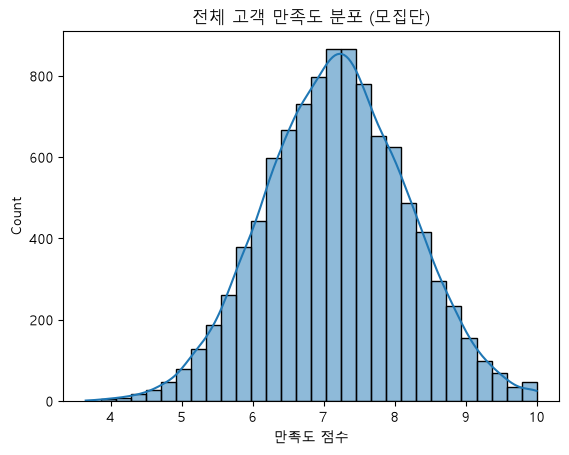

In [33]:
# 모집단 생성 (고객 만족도 10,000명)
np.random.seed(2025)
population = np.random.normal(loc=7.2, scale=1.0, size=10000)
population = np.clip(population, 1, 10)

# 모집단 시각화
sns.histplot(population, bins=30, kde=True)
plt.title("전체 고객 만족도 분포 (모집단)")
plt.xlabel("만족도 점수")
plt.show()

**📌 아래를 수행해 보세요:**

- 모집단을 생성하고, 거기서 표본을 40명 뽑아 평균을 계산해봅시다.

- 표본 평균과 표준편차를 바탕으로 95% 신뢰구간을 계산해봅시다.

- 히스토그램을 그리고 신뢰구간을 시각화해봅시다.

- 이 결과를 어떻게 해석하고, 마케팅 전략에 활용할 수 있을지 생각해봅시다.

In [34]:
# [문제 5] Q1. 모집단에서 표본 40명을 무작위로 추출하고, 표본 평균과 표준편차를 구해봅시다.
np.random.seed(2025)

n = 40
sample = np.random.choice(population, size=n, replace=False)

sample_mean = sample.mean()
sample_std = sample.std(ddof=1)   # 표본표준편차 (n-1로 나눔)

print(f"표본 평균: {sample_mean:.4f}")
print(f"표본 표준편차: {sample_std:.4f}")

표본 평균: 7.2258
표본 표준편차: 0.8973


In [35]:
# [문제 5] Q2. 표준오차(SE)를 구하고, t-분포를 사용하여 95% 신뢰구간을 계산해봅시다.
se = sample_std / np.sqrt(n)

confidence = 0.95
df = n - 1
t_critical = stats.t.ppf(1 - (1 - confidence) / 2, df=df)

margin_of_error = t_critical * se

ci_lower = sample_mean - margin_of_error
ci_upper = sample_mean + margin_of_error

print(f"표준오차(SE): {se:.4f}")
print(f"t-critical 값 (df={df}): {t_critical:.4f}")
print(f"오차범위(margin of error): {margin_of_error:.4f}")
print(f"95% 신뢰구간 (t-분포): ({ci_lower:.4f}, {ci_upper:.4f})")

표준오차(SE): 0.1419
t-critical 값 (df=39): 2.0227
오차범위(margin of error): 0.2870
95% 신뢰구간 (t-분포): (6.9388, 7.5128)


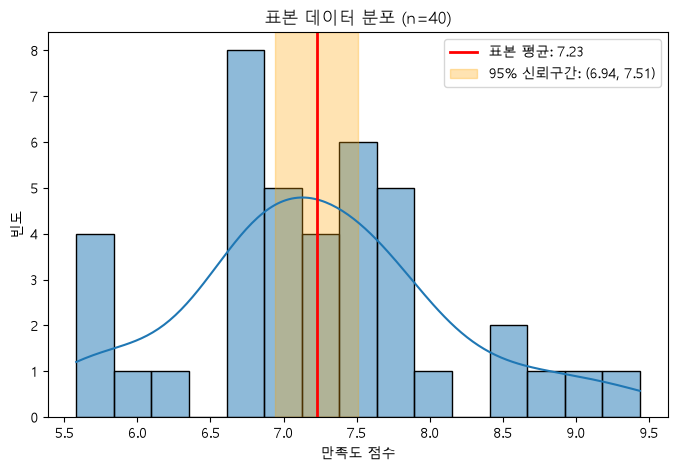

In [36]:
# [문제 5] Q3. 표본 데이터의 히스토그램을 그리고, 평균 및 신뢰구간을 함께 시각화해봅시다.
plt.figure(figsize=(8, 5))

sns.histplot(sample, bins=15, kde=True)

# 표본 평균선
plt.axvline(sample_mean, color='red', linestyle='-', linewidth=2, 
            label=f'표본 평균: {sample_mean:.2f}')

# 신뢰구간 범위 (음영 표시)
plt.axvspan(ci_lower, ci_upper, color='orange', alpha=0.3, 
            label=f'95% 신뢰구간: ({ci_lower:.2f}, {ci_upper:.2f})')

plt.title(f"표본 데이터 분포 (n={n})")
plt.xlabel("만족도 점수")
plt.ylabel("빈도")
plt.legend()
plt.show()

In [41]:
# [문제 5] Q4. 신뢰구간의 결과에 따라 어떤 구체적인 마케팅 전략을 세울 수 있을까요?
print("[Q4. 마케팅 전략 제안]")
print(f"95% 신뢰구간이 ({ci_lower:.2f}, {ci_upper:.2f})로 나왔다면, 전체 고객의 평균 만족도는")
print("대략 이 범위 안에 있다고 볼 수 있습니다. 이를 마케팅 전략에 활용한다면:")
print()
print("1) 신뢰구간의 하한값이 특정 기준점(예: 7.0점)을 넘는다면, '고객 만족도 7점 이상'과")
print("   같은 문구를 통계적 근거를 가지고 마케팅 메시지로 활용할 수 있습니다.")
print()
print("2) 신뢰구간의 폭이 넓다면(불확실성이 크다면), 표본 크기를 늘려서 더 정밀한 추정치를")
print("   확보한 뒤 의사결정을 내리는 것이 안전합니다. 반대로 폭이 좁고 신뢰할 만하다면")
print("   현재 표본만으로도 전략을 실행할 근거로 삼을 수 있습니다.")
print()
print("3) 신제품 출시나 서비스 개선 전후로 각각 신뢰구간을 구해서 두 구간이 겹치지 않는다면,")
print("   그 변화가 우연이 아니라 실제로 유의미한 개선(또는 악화)이라고 판단하는 근거로 활용할 수 있습니다.")
print()
print("4) 지역별, 연령대별로 표본을 나눠 각각 신뢰구간을 구하면, 만족도가 상대적으로 낮은")
print("   구간이나 신뢰구간이 특히 넓은(데이터가 불안정한) 세그먼트를 찾아내어")
print("   해당 그룹을 타겟으로 한 맞춤형 마케팅이나 서비스 개선에 우선순위를 둘 수 있습니다.")

[Q4. 마케팅 전략 제안]
95% 신뢰구간이 (6.94, 7.51)로 나왔다면, 전체 고객의 평균 만족도는
대략 이 범위 안에 있다고 볼 수 있습니다. 이를 마케팅 전략에 활용한다면:

1) 신뢰구간의 하한값이 특정 기준점(예: 7.0점)을 넘는다면, '고객 만족도 7점 이상'과
   같은 문구를 통계적 근거를 가지고 마케팅 메시지로 활용할 수 있습니다.

2) 신뢰구간의 폭이 넓다면(불확실성이 크다면), 표본 크기를 늘려서 더 정밀한 추정치를
   확보한 뒤 의사결정을 내리는 것이 안전합니다. 반대로 폭이 좁고 신뢰할 만하다면
   현재 표본만으로도 전략을 실행할 근거로 삼을 수 있습니다.

3) 신제품 출시나 서비스 개선 전후로 각각 신뢰구간을 구해서 두 구간이 겹치지 않는다면,
   그 변화가 우연이 아니라 실제로 유의미한 개선(또는 악화)이라고 판단하는 근거로 활용할 수 있습니다.

4) 지역별, 연령대별로 표본을 나눠 각각 신뢰구간을 구하면, 만족도가 상대적으로 낮은
   구간이나 신뢰구간이 특히 넓은(데이터가 불안정한) 세그먼트를 찾아내어
   해당 그룹을 타겟으로 한 맞춤형 마케팅이나 서비스 개선에 우선순위를 둘 수 있습니다.


**🧠 데이터를 어떻게 읽을까요?**

- 신뢰구간은 몇 점에서 몇 점 사이인가요? -> (6.94, 7.51)

- 이 구간은 전체 모집단 평균을 포함하고 있나요? -> 넵

- 이 결과를 바탕으로 고객 만족도가 충분히 높다고 말할 수 있을까요? -> 음,,그냥 평균보다 좀 높은 정도?

- 만약 신뢰구간이 너무 넓게 나왔다면, 그 이유는 무엇이고 어떻게 개선할 수 있을까요? -> 신뢰수준 줄이기

In [40]:
# [문제 5] 데이터를 어떻게 읽을까요?
print("[1번 질문]")
print("95% 신뢰구간은 (6.94, 7.51)로 나왔습니다. 즉 표본을 바탕으로 추정했을 때,")
print("전체 고객의 평균 만족도는 대략 6.94점에서 7.51점 사이일 것이라고 볼 수 있습니다.")
print()

print("[2번 질문]")
print("모집단을 생성할 때 사용한 실제 평균(모수)은 7.2점이었습니다.")
print("이 값이 신뢰구간 (6.94, 7.51) 범위 안에 포함되어 있으므로,")
print("이번 표본으로 구한 신뢰구간은 실제 모집단 평균을 정확히 포함하고 있습니다.")
print()

print("[3번 질문]")
print("신뢰구간이 6.94~7.51 사이로 나왔다는 것은, 10점 만점 기준으로 봤을 때 중간(5점)보다")
print("확실히 높은 수준이라고 할 수 있습니다. 다만 '충분히 높다'는 것은 절대적인 기준이")
print("아니라 상대적인 판단이기 때문에, 업계 평균이나 이전 조사 결과, 혹은 목표로 삼은 만족도 기준점과 비교해봐야 더 정확하게 판단할 수 있습니다.")
print("예를 들어 목표가 8점 이상이었다면 이 결과는 아직 개선이 필요하다고 볼 수 있고,")
print("목표가 7점이었다면 목표를 달성했다고 볼 수 있습니다.")
print()

print("[4번 질문]")
print("신뢰구간이 너무 넓게 나오는 주된 이유는 표본 크기(n)가 작거나, 표본 데이터의 퍼짐(표준편차)이 크기 때문입니다.")
print("표준오차 공식(SE = σ/√n)에서 알 수 있듯, n이 작을수록 SE가 커지고 그만큼 신뢰구간도 넓어집니다.")
print("이를 개선하려면 표본 크기를 늘려 더 많은 고객을 조사하는 것이 가장 직접적인 방법이며,")
print("측정 도구나 설문 방식을 개선해서 응답의 변동성(표준편차) 자체를 줄이는 것도 신뢰구간을 좁히는 데 도움이 될 수 있습니다.")

[1번 질문]
95% 신뢰구간은 (6.94, 7.51)로 나왔습니다. 즉 표본을 바탕으로 추정했을 때,
전체 고객의 평균 만족도는 대략 6.94점에서 7.51점 사이일 것이라고 볼 수 있습니다.

[2번 질문]
모집단을 생성할 때 사용한 실제 평균(모수)은 7.2점이었습니다.
이 값이 신뢰구간 (6.94, 7.51) 범위 안에 포함되어 있으므로,
이번 표본으로 구한 신뢰구간은 실제 모집단 평균을 정확히 포함하고 있습니다.

[3번 질문]
신뢰구간이 6.94~7.51 사이로 나왔다는 것은, 10점 만점 기준으로 봤을 때 중간(5점)보다
확실히 높은 수준이라고 할 수 있습니다. 다만 '충분히 높다'는 것은 절대적인 기준이
아니라 상대적인 판단이기 때문에, 업계 평균이나 이전 조사 결과, 혹은 목표로 삼은 만족도 기준점과 비교해봐야 더 정확하게 판단할 수 있습니다.
예를 들어 목표가 8점 이상이었다면 이 결과는 아직 개선이 필요하다고 볼 수 있고,
목표가 7점이었다면 목표를 달성했다고 볼 수 있습니다.

[4번 질문]
신뢰구간이 너무 넓게 나오는 주된 이유는 표본 크기(n)가 작거나, 표본 데이터의 퍼짐(표준편차)이 크기 때문입니다.
표준오차 공식(SE = σ/√n)에서 알 수 있듯, n이 작을수록 SE가 커지고 그만큼 신뢰구간도 넓어집니다.
이를 개선하려면 표본 크기를 늘려 더 많은 고객을 조사하는 것이 가장 직접적인 방법이며,
측정 도구나 설문 방식을 개선해서 응답의 변동성(표준편차) 자체를 줄이는 것도 신뢰구간을 좁히는 데 도움이 될 수 있습니다.
